# 07 — Visualisierung

**Ziel:** Die Schluss-Karten fuer das Slide-Deck und die Live-Demo erstellen:
1. Folium-Web-Karte (interaktiv) — `reports/figures/score_map.html`
2. Statische Karte mit OSM-Hintergrund — `reports/figures/score_map.png`
3. Top-/Flop-10-Quartiere als Balken — `reports/figures/topflop_quartiere.png`

## 1. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from zh15min import config, viz

## 2. Daten laden

In [2]:
hex_score = gpd.read_file(config.PROCESSED_DIR / 'zh_score.gpkg', layer='hex_score').to_crs(config.EPSG_LV95)
quart_summary = gpd.read_file(config.PROCESSED_DIR / 'zh_quartier_summary.gpkg', layer='quartiere').to_crs(config.EPSG_LV95)
print(f'{len(hex_score):,} Zellen | {len(quart_summary)} Quartiere')

744 Zellen | 34 Quartiere


## 3. Statische Karte (PNG fuer die Slides)

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/score_map.png


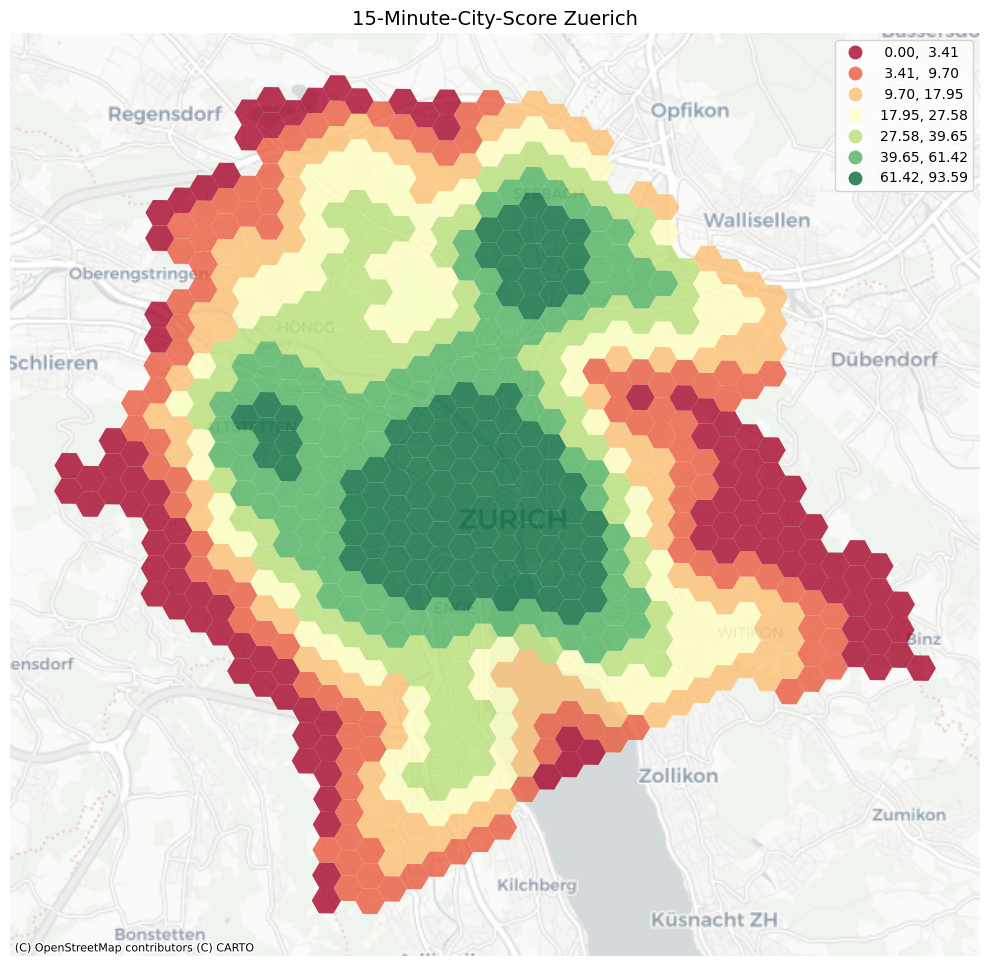

In [3]:
fig, ax = viz.style_score_static(hex_score, title='15-Minute-City-Score Zuerich')
out = config.FIGURES_DIR / 'score_map.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print('Gespeichert:', out)

## 4. Folium-Karte (interaktiv)

In [4]:
m = viz.folium_score(hex_score, quart_summary=quart_summary)
out = config.FIGURES_DIR / 'score_map.html'
m.save(str(out))
print('Gespeichert:', out)
m

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/score_map.html


## 5. Top-/Flop-Quartiere

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/topflop_quartiere.png


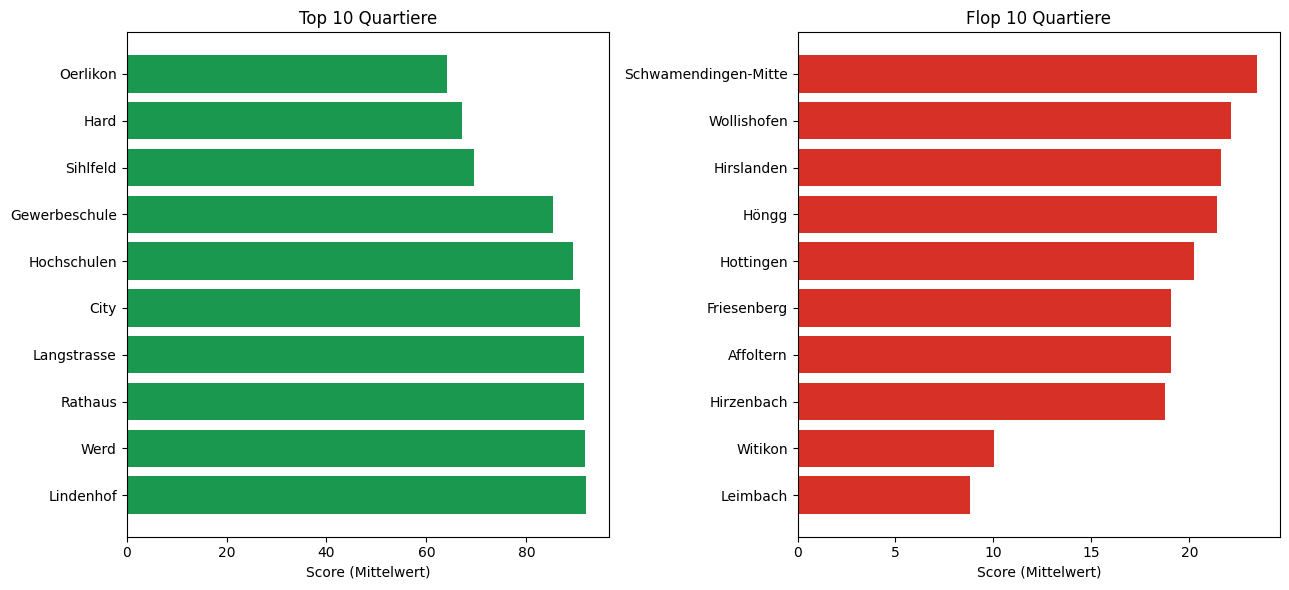

In [5]:
name_col = next((c for c in quart_summary.columns if 'name' in c.lower()), None)
if name_col is None:
    raise RuntimeError('Quartier-Namensspalte nicht gefunden')

ranking = quart_summary[[name_col, 'score_mean']].dropna().sort_values('score_mean', ascending=False)
top = ranking.head(10).iloc[::-1]
flop = ranking.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(top[name_col], top['score_mean'], color='#1a9850')
axes[0].set_title('Top 10 Quartiere')
axes[0].set_xlabel('Score (Mittelwert)')
axes[1].barh(flop[name_col], flop['score_mean'], color='#d73027')
axes[1].set_title('Flop 10 Quartiere')
axes[1].set_xlabel('Score (Mittelwert)')
for ax in axes:
    ax.invert_yaxis()
fig.tight_layout()
out = config.FIGURES_DIR / 'topflop_quartiere.png'
fig.savefig(out, dpi=180, bbox_inches='tight')
print('Gespeichert:', out)

## 6. Score-Verteilung (Histogramm)

Hilft in der Diskussion zu zeigen, wie viel der Stadt im 'gruenen' Bereich liegt.

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/score_histogram.png


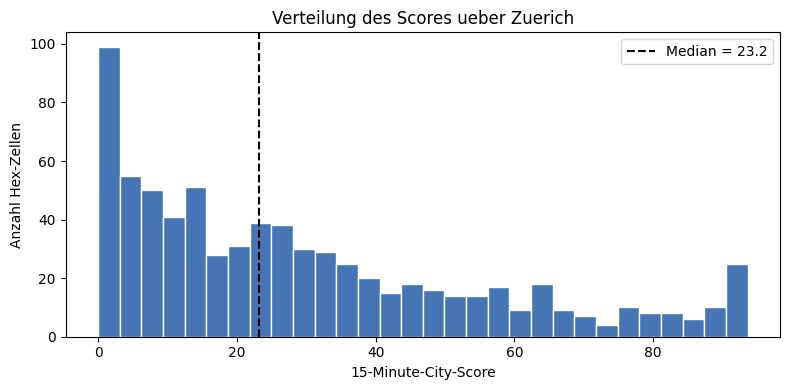

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hex_score['score'].dropna(), bins=30, color='#4575b4', edgecolor='white')
ax.axvline(hex_score['score'].median(), color='black', linestyle='--', label=f'Median = {hex_score["score"].median():.1f}')
ax.set_xlabel('15-Minute-City-Score')
ax.set_ylabel('Anzahl Hex-Zellen')
ax.set_title('Verteilung des Scores ueber Zuerich')
ax.legend()
fig.tight_layout()
out = config.FIGURES_DIR / 'score_histogram.png'
fig.savefig(out, dpi=180, bbox_inches='tight')
print('Gespeichert:', out)

## 7. Zusammenfassung

Alle wichtigen Karten und Plots liegen jetzt in `reports/figures/`. Sie werden im Slide-Deck eingebunden.